In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [13]:
# GANTI NILAI DI BAWAH DENGAN NIM ANDA LENGKAP
NIM = 24146063

# Path ke direktori dataset hasil ekstraksi dari Kaggle
# Pastikan folder 'flowers' berisi 5 subfolder: daisy, dandelion, rose, sunflower, tulip
DATASET_DIR = './flowers'
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
IMG_SIZE = (64, 64)  # Dimensi seragam untuk citra (64x64)

In [14]:
X = []
y = []
image_paths = []

print("Memulai proses load dan preprocessing citra...")

for label_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(DATASET_DIR, class_name)
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} tidak ditemukan!")
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Baca citra menggunakan OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Konversi warna dari BGR ke RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize gambar ke ukuran seragam
        img_resized = cv2.resize(img_rgb, IMG_SIZE)

        # Ekstraksi fitur: Flatten matriks 2D/3D menjadi vektor 1D
        img_flatten = img_resized.flatten()

        X.append(img_flatten)
        y.append(label_idx)
        image_paths.append((img_path, class_name))

# Normalisasi nilai piksel ke rentang [0, 1]
X = np.array(X, dtype='float32') / 255.0
y = np.array(y)

print(f"Total citra berhasil diproses: {len(X)} gambar.")

Memulai proses load dan preprocessing citra...
Total citra berhasil diproses: 4317 gambar.


In [15]:
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X,
    y,
    image_paths,
    test_size=0.2,
    random_state=NIM
)

print(f"Jumlah Data Training : {len(X_train)}")
print(f"Jumlah Data Testing  : {len(X_test)}")

Jumlah Data Training : 3453
Jumlah Data Testing  : 864


In [16]:
print("\nMelatih model Multi-Layer Perceptron (MLP)...")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=NIM,
    verbose=True
)

mlp.fit(X_train, y_train)


Melatih model Multi-Layer Perceptron (MLP)...
Iteration 1, loss = 2.10326033
Iteration 2, loss = 1.34514424
Iteration 3, loss = 1.25837759
Iteration 4, loss = 1.22576181
Iteration 5, loss = 1.18695663
Iteration 6, loss = 1.21441137
Iteration 7, loss = 1.12804206
Iteration 8, loss = 1.12493933
Iteration 9, loss = 1.09455134
Iteration 10, loss = 1.12560228
Iteration 11, loss = 1.06282890
Iteration 12, loss = 1.05070910
Iteration 13, loss = 1.02229606
Iteration 14, loss = 1.03052791
Iteration 15, loss = 0.93287643
Iteration 16, loss = 0.96996465
Iteration 17, loss = 0.92870149
Iteration 18, loss = 1.01478208
Iteration 19, loss = 0.98223845
Iteration 20, loss = 0.86760230
Iteration 21, loss = 0.84796162
Iteration 22, loss = 0.82112753
Iteration 23, loss = 0.78393697
Iteration 24, loss = 0.77810554
Iteration 25, loss = 0.71433943
Iteration 26, loss = 0.69206605
Iteration 27, loss = 0.66615040
Iteration 28, loss = 0.67765680
Iteration 29, loss = 0.63797157
Iteration 30, loss = 0.60959705
It

MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=24146063,
              verbose=True)

In [17]:
y_pred = mlp.predict(X_test)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       daisy     0.5517    0.2078    0.3019       154
   dandelion     0.4192    0.5674    0.4822       215
        rose     0.4859    0.4313    0.4570       160
   sunflower     0.6019    0.4676    0.5263       139
       tulip     0.3774    0.5102    0.4338       196

    accuracy                         0.4491       864
   macro avg     0.4872    0.4369    0.4402       864
weighted avg     0.4751    0.4491    0.4415       864



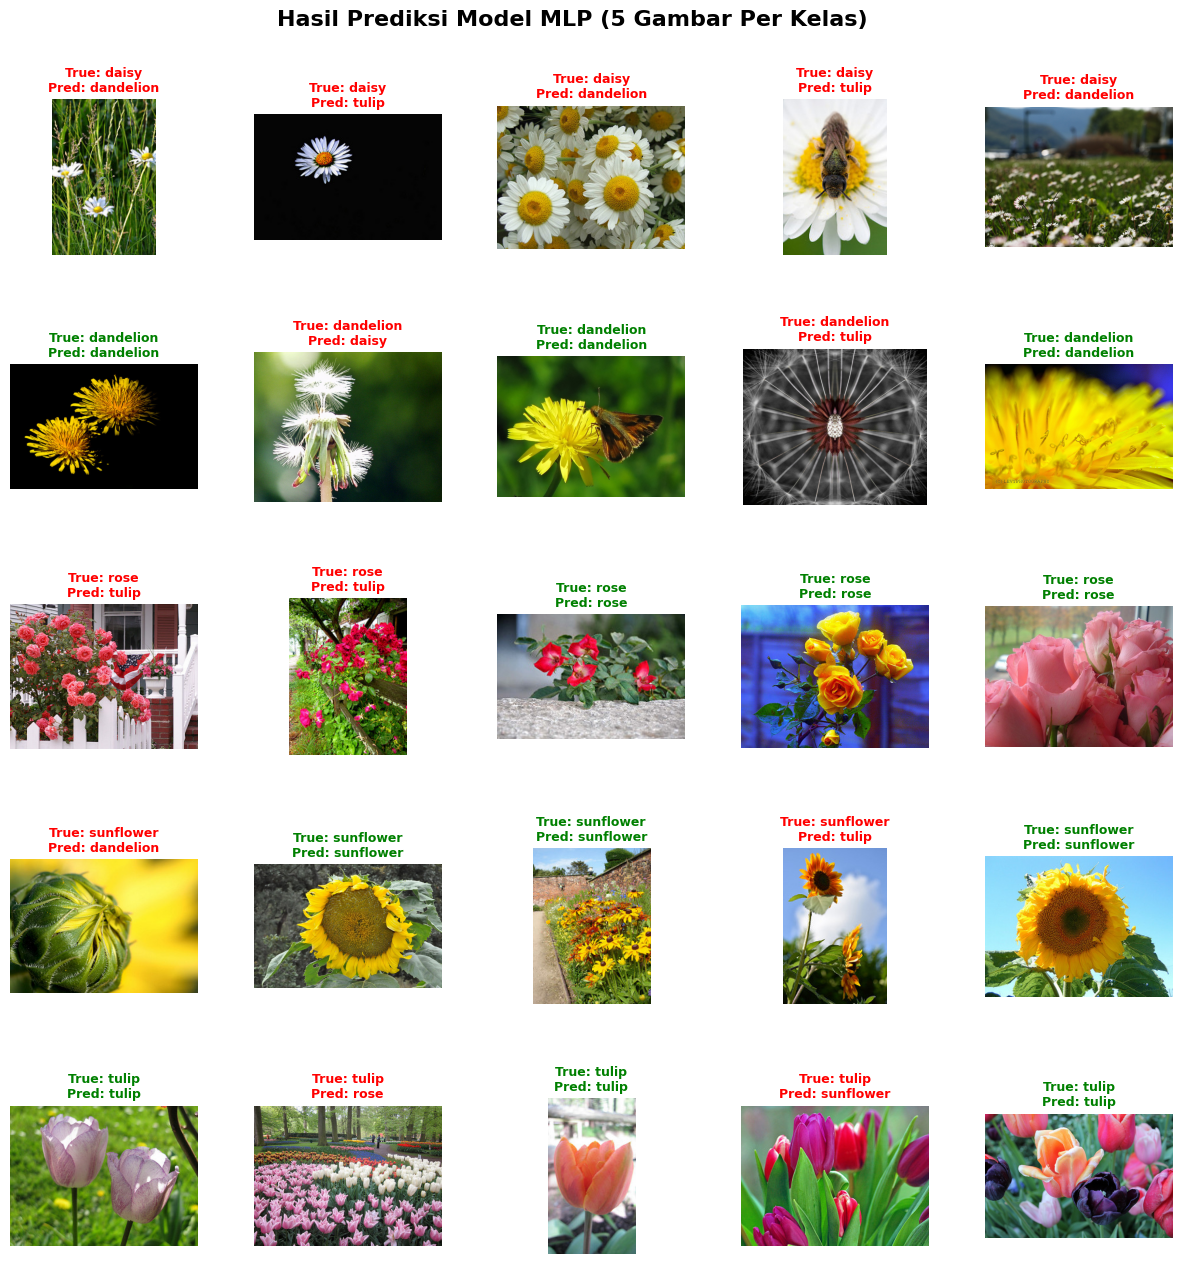

In [18]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
plt.subplots_adjust(hspace=0.6, wspace=0.3)

for cls_idx, class_name in enumerate(CLASSES):
    # Filter data uji berdasarkan kelas aslinya
    indices = [i for i, path_tuple in enumerate(paths_test) if path_tuple[1] == class_name]

    # Ambil 5 sampel acak dari kelas tersebut
    np.random.seed(NIM)
    selected_indices = np.random.choice(indices, size=5, replace=False)

    for col_idx, idx in enumerate(selected_indices):
        img_path, true_label_str = paths_test[idx]
        pred_label_str = CLASSES[y_pred[idx]]

        # Baca gambar asli untuk visualisasi
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[cls_idx, col_idx]
        ax.imshow(img_rgb)
        ax.axis('off')

        # Label berwarna hijau jika prediksi benar, merah jika salah
        text_color = 'green' if true_label_str == pred_label_str else 'red'
        ax.set_title(
            f"True: {true_label_str}\nPred: {pred_label_str}",
            fontsize=9,
            color=text_color,
            fontweight='bold'
        )

plt.suptitle("Hasil Prediksi Model MLP (5 Gambar Per Kelas)", fontsize=16, fontweight='bold', y=0.94)
plt.show()